<a href="https://colab.research.google.com/github/Sathvik97/InitialRepo/blob/main/SocialLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

In [2]:
def add_noise(traj, sigma=0.1):
    noise = np.random.normal(0, sigma, traj.shape)
    return traj + noise

In [3]:
def build_grid(target, neighbors, grid_size=4, cell_size=1.0):
    grid = np.zeros((grid_size, grid_size))

    center = grid_size // 2

    for nx, ny in neighbors:
        dx = nx - target[0]
        dy = ny - target[1]

        gx = int(dx / cell_size) + center
        gy = int(dy / cell_size) + center

        if 0 <= gx < grid_size and 0 <= gy < grid_size:
            grid[gx, gy] = 1

    return grid.flatten()

In [4]:
class SocialLSTM(nn.Module):
    def __init__(self,
                 pos_dim    = 2,
                 social_dim = 16,   # 16
                 embed_dim  = 64,
                 hidden_dim = 64,
                 pred_len   = 6):
        super().__init__()
        self.pred_len = pred_len

        # FIX: declare the layers that forward() uses
        self.pos_fc    = nn.Linear(pos_dim,    embed_dim)
        self.social_fc = nn.Linear(social_dim, embed_dim)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc        = nn.Linear(hidden_dim, pos_dim)

    def forward(self, x, social):
        B, T, _ = x.shape          # FIX: indentation — body must be inside forward

        embeddings = []
        for t in range(T):
            pos = x[:, t, :]        # (B, 2)
            soc = social[:, t, :]   # (B, 16)

            pos_emb = torch.relu(self.pos_fc(pos))      # (B, 64)
            soc_emb = torch.relu(self.social_fc(soc))   # (B, 64)

            combined = pos_emb + soc_emb                # (B, 64)
            embeddings.append(combined)

        embeddings = torch.stack(embeddings, dim=1)     # (B, T, 64)

        _, (h, c) = self.lstm(embeddings)               # h: (1, B, hidden)


        dec_input = x[:, -1:, :]   # (B, 1, 2) — last observed step
        outputs   = []
        for _ in range(self.pred_len):
            pos_emb  = torch.relu(self.pos_fc(dec_input.squeeze(1)))
            soc_zero = torch.zeros(B, 16, device=x.device)  # no future social
            soc_emb  = torch.relu(self.social_fc(soc_zero))
            combined = (pos_emb + soc_emb).unsqueeze(1)             # (B,1,64)
            out, (h, c) = self.lstm(combined, (h, c))
            step = self.fc(out)          # (B, 1, 2)
            outputs.append(step)
            dec_input = step             # teacher-forcing off at inference

        return torch.cat(outputs, dim=1)     # (B, pred_len, 2)

In [5]:
import json
from collections import defaultdict

def load_data(data_dir="."):
    with open("sample_annotation.json") as f:
        annotations = json.load(f)
    with open("instance.json") as f:
        instances = json.load(f)
    with open("category.json") as f:
        categories = json.load(f)
    with open("sample.json") as f:                          # ADD THIS
        samples = json.load(f)

    cat_map = {c["token"]: c["name"] for c in categories}
    sample_order = {s["token"]: s["timestamp"] for s in samples}  # ADD THIS

    ped_tokens = {
        i["token"]
        for i in instances
        if "human.pedestrian" in cat_map.get(i["category_token"], "")
    }

    trajectories = defaultdict(list)
    for ann in annotations:
        if ann["instance_token"] in ped_tokens:
            trajectories[ann["instance_token"]].append((
                ann["sample_token"],
                ann["translation"][0],
                ann["translation"][1],
            ))

    frame_map = defaultdict(list)
    for ann in annotations:
        if ann["instance_token"] in ped_tokens:
            frame_map[ann["sample_token"]].append((
                ann["instance_token"],
                ann["translation"][0],
                ann["translation"][1],
            ))

    for pid in trajectories:                                # now sample_order exists
        trajectories[pid].sort(key=lambda x: sample_order.get(x[0], 0))

    return trajectories, frame_map

In [6]:
trajectories, frame_map = load_data(".")

In [7]:
with open("sample.json") as f:
    samples = json.load(f)
sample_order = {s["token"]: s["timestamp"] for s in samples}

first_ped = list(trajectories.keys())[0]
for row in trajectories[first_ped][:10]:
    print(sample_order.get(row[0], "NOT FOUND"), row)

1532402927647951 ('ca9a282c9e77460f8360f564131a8af5', 373.256, 1130.419)
1532402928147847 ('39586f9d59004284a7114a68825e8eec', 373.256, 1130.419)
1532402928698048 ('356d81f38dd9473ba590f39e266f54e5', 373.256, 1130.419)
1532402929197353 ('e0845f5322254dafadbbed75aaa07969', 373.256, 1130.419)
1532402929697797 ('c923fe08b2ff4e27975d2bf30934383b', 373.256, 1130.419)
1532402930152601 ('f1e3d9d08f044c439ce86a2d6fcca57b', 373.256, 1130.419)
1532402930648325 ('4f545737bf3347fbbc9af60b0be9a963', 373.256, 1130.419)
1532402931198511 ('7626dde27d604ac28a0240bdd54eba7a', 373.256, 1130.419)
1532402931697833 ('be99ffc878b24aca8956bbb4e0f97d0c', 373.256, 1130.419)
1532402932197715 ('9813c23a5f1448b09bb7910fea9baf20', 373.256, 1130.419)


In [8]:
def build_windows(trajectories, frame_map):
    obs_windows    = []
    target_windows = []
    social_windows = []
    OBS_LEN     = 4
    PRED_LEN    = 6
    WINDOW_SIZE = OBS_LEN + PRED_LEN

    for ped_id, path in trajectories.items():
        # path is a list of (sample_token, x, y) sorted by time
        if len(path) < WINDOW_SIZE:
            continue

        sample_tokens = [p[0] for p in path]
        coords        = np.array([[p[1], p[2]] for p in path])  # (T, 2)

        for i in range(len(coords) - WINDOW_SIZE + 1):
            window        = coords[i : i + WINDOW_SIZE].copy()
            token_window  = sample_tokens[i : i + WINDOW_SIZE]

            # Normalise to first observed position
            origin = window[0].copy()
            window = window - origin

            # Displacement sequence
            disp       = np.zeros_like(window)
            disp[1:]   = window[1:] - window[:-1]

            # Social grids for observation frames only
            social_seq = []
            for t in range(OBS_LEN):
                time_token = token_window[t]
                target_pos = window[t]                    # normalised

                neighbors = []
                for pid, nx, ny in frame_map[time_token]:
                    if pid != ped_id:
                        neighbors.append((nx - origin[0], ny - origin[1]))

                grid = build_grid(target_pos, neighbors)
                social_seq.append(grid)

            social_seq = np.array(social_seq)   # (OBS_LEN, 16)

            obs_windows.append(disp[:OBS_LEN])          # (OBS_LEN, 2)
            target_windows.append(disp[OBS_LEN:])        # (PRED_LEN, 2)
            social_windows.append(social_seq)            # (OBS_LEN, 16)

    return (np.array(obs_windows),
            np.array(target_windows),
            np.array(social_windows))

In [9]:
def ade(pred, gt):
    pred_pos = np.cumsum(pred, axis=0)
    gt_pos   = np.cumsum(gt,   axis=0)
    return np.sqrt(((pred_pos - gt_pos) ** 2).sum(-1)).mean()


def fde(pred, gt):
    pred_pos = np.cumsum(pred, axis=0)
    gt_pos   = np.cumsum(gt,   axis=0)
    return np.sqrt(((pred_pos[-1] - gt_pos[-1]) ** 2).sum())

In [10]:

def train(obs_np, target_np, social_np, epochs=100, lr=5e-4, batch=64):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    obs_t    = torch.tensor(obs_np,    dtype=torch.float32).to(device)
    target_t = torch.tensor(target_np, dtype=torch.float32).to(device)
    social_t = torch.tensor(social_np, dtype=torch.float32).to(device)

    dataset = torch.utils.data.TensorDataset(obs_t, social_t, target_t)
    loader  = torch.utils.data.DataLoader(dataset, batch_size=batch, shuffle=True)

    model     = SocialLSTM().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for obs_b, soc_b, tgt_b in loader:
            pred = model(obs_b, soc_b)      # (B, pred_len, 2)
            loss = criterion(pred, tgt_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(loader)}")



    return model

In [11]:
obs_np, target_np, social_np = build_windows(trajectories, frame_map)
from sklearn.model_selection import train_test_split
(obs_train, obs_test,
     tgt_train, tgt_test,
     soc_train, soc_test) = train_test_split(
        obs_np, target_np, social_np,
        test_size=0.2,      # 80% train, 20% test
        random_state=42,
    )


EPOCHS = 100

    # ── Train ───────────────────────────────────────────────────
model = train(obs_train, tgt_train, soc_train, epochs=100)

    # ── Evaluate on test set ────────────────────────────────────
model.eval()
device = next(model.parameters()).device

with torch.no_grad():
    pred = model(
        torch.tensor(obs_test,dtype=torch.float32 ,device=device),

        torch.tensor(soc_test,dtype=torch.float32 ,device=device),
        ).cpu().numpy()

    ades = [ade(pred[i], tgt_test[i]) for i in range(len(pred))]
    fdes = [fde(pred[i], tgt_test[i]) for i in range(len(pred))]

    print(np.mean(ades))
    print(np.mean(fdes))



Epoch 10/100, Loss: 0.011823629355058074
Epoch 20/100, Loss: 0.011252885276917368
Epoch 30/100, Loss: 0.010622567741665988
Epoch 40/100, Loss: 0.010199521854519843
Epoch 50/100, Loss: 0.010070469684433193
Epoch 60/100, Loss: 0.009756760124582797
Epoch 70/100, Loss: 0.00982597793918103
Epoch 80/100, Loss: 0.009260030568111689
Epoch 90/100, Loss: 0.009017954545561225
Epoch 100/100, Loss: 0.008724344859365374
0.2639181461757309
0.47825851673400266


In [110]:
def reconstuct_traj(disp):
  traj = [np.array([0.0,0.0])]

  for d in disp:
    traj.append(traj[-1] + d)

  return np.array(traj[1:])

In [129]:
val_dataset = torch.utils.data.TensorDataset(
    torch.tensor(obs_test, dtype=torch.float32),
    torch.tensor(soc_test, dtype=torch.float32),
    torch.tensor(tgt_test, dtype=torch.float32)
)

val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

In [12]:
import matplotlib.pyplot as plt

def visualize_predictions(obs_np, tgt_test, pred, n_samples=6):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i in range(n_samples):
        ax = axes[i]

        # convert displacements to absolute positions
        obs_pos  = np.cumsum(obs_np[i],  axis=0)   # (OBS_LEN, 2)
        gt_pos   = np.cumsum(tgt_test[i], axis=0)  # (PRED_LEN, 2)
        pred_pos = np.cumsum(pred[i],     axis=0)  # (PRED_LEN, 2)

        # shift gt and pred to start from last observed point
        origin   = obs_pos[-1]
        gt_pos   = gt_pos   + origin
        pred_pos = pred_pos + origin

        # past trajectory
        ax.scatter(obs_pos[:, 0], obs_pos[:, 1],
                   c="blue", s=50, zorder=3, label="observed")
        ax.plot(obs_pos[:, 0], obs_pos[:, 1],
                c="blue", linewidth=1.5, alpha=0.6)

        # ground truth future
        ax.scatter(gt_pos[:, 0], gt_pos[:, 1],
                   c="green", s=50, zorder=3, label="ground truth")
        ax.plot(gt_pos[:, 0], gt_pos[:, 1],
                c="green", linewidth=1.5, alpha=0.6)

        # predicted future
        ax.scatter(pred_pos[:, 0], pred_pos[:, 1],
                   c="red", s=50, zorder=3, label="predicted")
        ax.plot(pred_pos[:, 0], pred_pos[:, 1],
                c="red", linewidth=1.5, alpha=0.6)

        # mark start and end
        ax.scatter(*obs_pos[0],  c="black",  s=100, zorder=4, marker="^", label="start")
        ax.scatter(*gt_pos[-1],  c="green",  s=100, zorder=4, marker="*")
        ax.scatter(*pred_pos[-1],c="red",    s=100, zorder=4, marker="*")

        sample_ade = ade(pred[i], tgt_test[i])
        sample_fde = fde(pred[i], tgt_test[i])
        ax.set_title(f"Sample {i+1} | ADE: {sample_ade:.2f}m  FDE: {sample_fde:.2f}m")
        ax.legend(fontsize=7)
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.grid(True, alpha=0.3)
        ax.set_aspect("equal")

    plt.suptitle("Social LSTM — Trajectory Predictions", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("trajectory_predictions.png", dpi=150)
    plt.show()
    print("saved to trajectory_predictions.png")

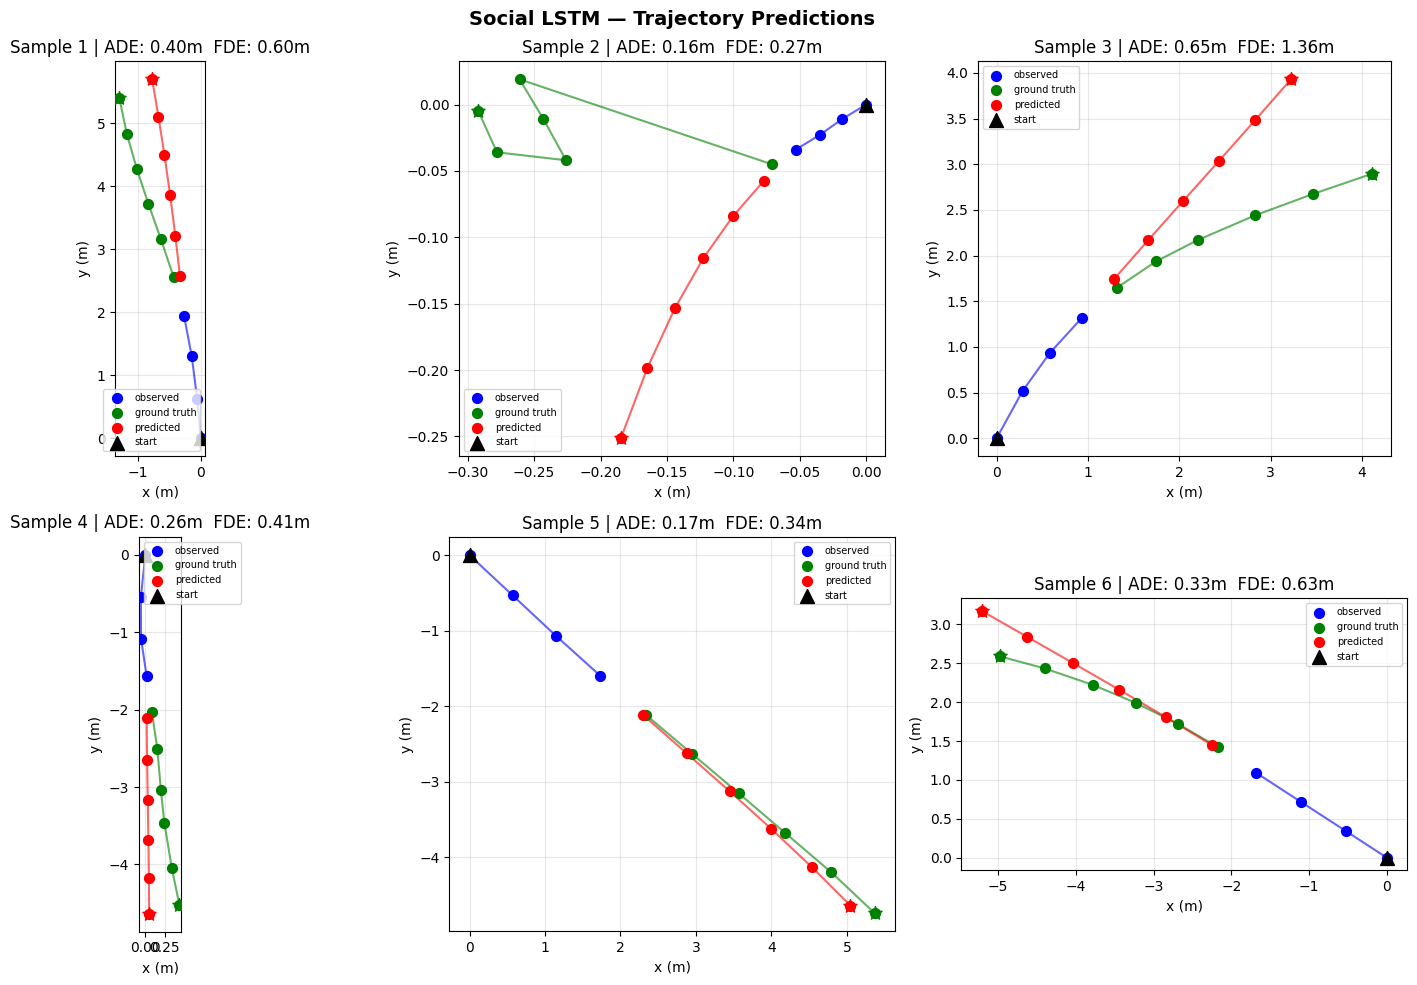

saved to trajectory_predictions.png


In [13]:
visualize_predictions(obs_test, tgt_test, pred, n_samples=6)